## Exercise 2.1: ε-greedy 행동 선택

ε-greedy 행동 선택에서는 확률 $1 - \varepsilon + \dfrac{\varepsilon}{\text{행동 수}}$로 탐욕적 행동을 선택하고, 확률 $\dfrac{\varepsilon}{\text{행동 수}}$로 비탐욕적(탐험) 행동을 선택한다.

행동이 두 개($\text{행동 수} = 2$)이고 $\varepsilon = 0.5$인 경우, 탐욕적 행동을 선택할 확률은 다음과 같다.

$$1 - \varepsilon + \frac{\varepsilon}{\text{행동 수}}$$

값을 대입하면

$$1 - 0.5 + \frac{0.5}{2} = 1 - 0.5 + 0.25 = 0.75$$

따라서 행동이 두 개이고 $\varepsilon = 0.5$일 때 탐욕적 행동이 선택될 확률은 $0.75$, 즉 75%이다.

## Exercise 2.2: 밴딧 예제

### 주어진 정보

- 행동의 수 $k = 4$이며, 행동은 1, 2, 3, 4로 표기한다.
- 모든 행동에 대해 초기 추정값은 $Q_1(a) = 0$이다.
- 행동과 보상의 수열은 $A_1 = 1, R_1 = -1$, $A_2 = 2, R_2 = 1$, $A_3 = 2, R_3 = -2$, $A_4 = 2, R_4 = 2$, $A_5 = 3, R_5 = 0$이다.
- 행동 선택 방식은 $\epsilon$-greedy로, 확률 $\epsilon$로 무작위 행동을, 확률 $1 - \epsilon$로 추정값이 가장 큰 행동을 선택한다.
- 행동 가치 추정에는 표본 평균(sample average) 방식을 사용한다.

### 단계별 분석

1. **초기 상태:**
   - $Q_1(1) = Q_1(2) = Q_1(3) = Q_1(4) = 0$.

2. **단계 1 — $A_1 = 1$, $R_1 = -1$:**
   - 행동 1의 $Q$ 값을 갱신한다.
     $$Q_2(1) = \frac{-1}{1} = -1$$
   - $Q_2(2) = 0$, $Q_2(3) = 0$, $Q_2(4) = 0$.
   - 모든 초기 $Q$ 값이 같았으므로, 이 시점의 행동 1 선택은 탐욕적 선택일 수도, 탐험적 선택일 수도 있다.

3. **단계 2 — $A_2 = 2$, $R_2 = 1$:**
   - 행동 2의 $Q$ 값을 갱신한다.
     $$Q_3(2) = \frac{1}{1} = 1$$
   - $Q_3(1) = -1$, $Q_3(3) = 0$, $Q_3(4) = 0$.
   - $Q_2(1) = -1$이고 $Q_2(2) = 0$이므로, 행동 2는 추정값이 가장 큰 탐욕적 선택일 수도 있고 탐험적 선택일 수도 있다.

4. **단계 3 — $A_3 = 2$, $R_3 = -2$:**
   - 행동 2의 $Q$ 값을 갱신한다.
     $$Q_4(2) = \frac{1 + (-2)}{2} = -0.5$$
   - $Q_4(1) = -1$, $Q_4(3) = 0$, $Q_4(4) = 0$.
   - 직전 시점의 추정값에서는 $Q_3(2) = 1$이 가장 컸으므로, 이번 행동 2 선택은 탐욕적 선택으로 자연스럽게 설명된다.

5. **단계 4 — $A_4 = 2$, $R_4 = 2$:**
   - 행동 2의 $Q$ 값을 갱신한다.
     $$Q_5(2) = \frac{1 + (-2) + 2}{3} = \frac{1}{3} \approx 0.33$$
   - $Q_5(1) = -1$, $Q_5(3) = 0$, $Q_5(4) = 0$.
   - 그러나 직전 시점에서는 $Q_4(2) = -0.5$로, $Q_4(3) = 0$이나 $Q_4(4) = 0$보다 작았다. 따라서 행동 2를 다시 선택한 것은 탐욕적 선택으로 설명되지 않으며, 분명한 $\epsilon$-greedy(탐험) 선택이다.

6. **단계 5 — $A_5 = 3$, $R_5 = 0$:**
   - 행동 3의 $Q$ 값을 갱신한다.
     $$Q_6(3) = \frac{0}{1} = 0$$
   - $Q_6(1) = -1$, $Q_6(2) \approx 0.33$, $Q_6(3) = 0$, $Q_6(4) = 0$.
   - 직전 시점에서는 $Q_5(2) \approx 0.33$이 가장 큰 값이었으므로, 행동 3을 선택한 것 또한 분명한 $\epsilon$-greedy 선택이다.

### 결론

- **확실히 $\epsilon$-greedy(탐험) 선택인 경우:**
  - 단계 4: $A_4 = 2$ — 직전 시점에서 $Q_4(2) = -0.5$가 최대값이 아니었기 때문이다.
  - 단계 5: $A_5 = 3$ — 직전 시점에서 $Q_5(2) \approx 0.33$이 최대값이었기 때문이다.

- **$\epsilon$-greedy 선택일 가능성도 있는 경우:**
  - 단계 1: $A_1 = 1$ — 초기 $Q$ 값이 모두 같았으므로 임의의 선택일 수 있다.
  - 단계 2: $A_2 = 2$ — 탐욕적 선택으로도, 탐험적 선택으로도 설명할 수 있다.
  - 단계 3: $A_3 = 2$ — 직전 시점에서 $Q_3(2) = 1$이 최대값이었으므로 탐욕적 선택으로 자연스럽게 설명된다.

### $Q$ 값의 변화 표

| 단계 | 행동 ($A_t$) | 보상 ($R_t$) | $Q(1)$ | $Q(2)$ | $Q(3)$ | $Q(4)$ |
|------|------------------|------------------|----------|----------|----------|----------|
| 0    | -                | -                | 0        | 0        | 0        | 0        |
| 1    | 1                | -1               | -1       | 0        | 0        | 0        |
| 2    | 2                | 1                | -1       | 1        | 0        | 0        |
| 3    | 2                | -2               | -1       | -0.5     | 0        | 0        |
| 4    | 2                | 2                | -1       | 0.33     | 0        | 0        |
| 5    | 3                | 0                | -1       | 0.33     | 0        | 0        |

이 표는 매 시점 행동과 보상이 주어진 직후의 $Q$ 값 변화를 정리한 것으로, 각 단계에서 어떤 행동의 추정값이 가장 컸는지를 한눈에 비교하는 데 도움이 된다.

## Exercise 2.3

$\epsilon = 0.01$인 방법이 탐험과 활용 사이의 균형을 가장 잘 잡아 주며, 충분히 긴 시점에 걸쳐 더 높은 누적 보상과 더 큰 최적 행동 선택 확률을 보인다.

## Exercise 2.4

### 비상수 단계 크기에 대한 일반화

다음 갱신 규칙에서 출발한다.
$$Q_{n+1} = Q_n + \alpha_n (R_n - Q_n)$$

이를 재귀적으로 풀어, $Q_{n+1}$을 이전의 모든 보상과 단계 크기 매개변수에 대한 식으로 표현하고자 한다.

### 유도 과정

1. **초기값:**
   $$Q_1$$

2. **첫 번째 갱신:**
   $$Q_2 = Q_1 + \alpha_1 (R_1 - Q_1)$$

3. **두 번째 갱신:**
   $$Q_3 = Q_2 + \alpha_2 (R_2 - Q_2)$$

   $Q_2$를 대입하여 정리하면 다음과 같다.
   $$\begin{aligned}
   Q_3 =& Q_1 + \alpha_1 (R_1 - Q_1) + \alpha_2 (R_2 - (Q_1 + \alpha_1 (R_1 - Q_1))) \\
       =& Q_1 + \alpha_1 (R_1 - Q_1) + \alpha_2 (R_2 - Q_1 - \alpha_1 R_1 + \alpha_1 Q_1) \\
       =& Q_1 (1 - \alpha_1)(1 - \alpha_2) + \alpha_1 R_1 (1 - \alpha_2) + \alpha_2 R_2
   \end{aligned}$$

4. **일반항:**

   같은 방식으로 일반화하면, $Q_{n+1}$을 모든 이전 보상에 대한 식으로 다음과 같이 쓸 수 있다.
   $$Q_{n+1} = Q_1 \prod_{i=1}^n (1 - \alpha_i) + \sum_{k=1}^n \left[ \alpha_k R_k \prod_{j=k+1}^n (1 - \alpha_j) \right]$$

   각 보상 $R_k$에는 단계 크기 $\alpha_k$와, 그 이후 시점들의 $(1 - \alpha_j)$ 곱이 가중치로 작용하고 있음을 알 수 있다.

### 각 보상에 대한 가중치

따라서 $Q_{n+1}$에서 보상 $R_k$가 차지하는 가중치는 다음과 같다.
$$R_k\text{의 가중치} = \alpha_k \prod_{j=k+1}^n (1 - \alpha_j)$$

이 식은 단계 크기 매개변수의 수열에 따라 각 보상의 영향력이 시간이 지남에 따라 감소함을 보여 준다.

### 결론

단계 크기 매개변수 $\alpha_n$의 수열에 대한 식 (2.6)의 일반화 형태에서, 각 이전 보상에 대한 가중치는
$$\alpha_k \prod_{j=k+1}^n (1 - \alpha_j)$$
이다. 이는 단계 크기가 일정하지 않을 때 각 보상이 현재 추정값 $Q_n$에 어떻게 기여하는지를 명확히 드러낸다.

## Exercise 2.5 (프로그래밍)

Exercise 2.5에서는 비정상(nonstationary) 문제에서 표본 평균 방식이 겪는 어려움을 보이기 위한 실험을 설계한다. 10팔 밴딧(10-armed bandit) 문제 위에서 다음 두 방법을 비교한다.

1. 표본 평균을 이용하는 행동 가치 방법.
2. 일정한 단계 크기 $\alpha = 0.1$을 사용하는 행동 가치 방법.

### 실험 설정

1. **10팔 테스트베드:**
   - 각 행동 $a$의 초기 참값은 $q_*(a) = 0$으로 둔다.
   - 매 단계마다 모든 $q_*(a)$에 평균 0, 표준편차 0.01인 정규분포 증분을 더해 무작위 보행(random walk)을 시킨다.

2. **두 가지 방법:**
   - **표본 평균 방법:** 지금까지 관측된 모든 보상의 평균으로 행동 가치 추정값을 갱신한다.
   - **일정 단계 크기 방법:** 일정한 단계 크기 $\alpha = 0.1$을 사용하여 갱신한다.

3. **매개변수:**
   - $\epsilon = 0.1$의 $\epsilon$-greedy 행동 선택을 사용한다.
   - 한 번의 실행은 10,000 단계로 구성된다.
   - 통계적 신뢰성을 위해 여러 번 실행하며(예: 2,000회), 그 평균을 본다.

### 구현

다음은 NumPy와 Matplotlib을 사용한 파이썬 구현이다.

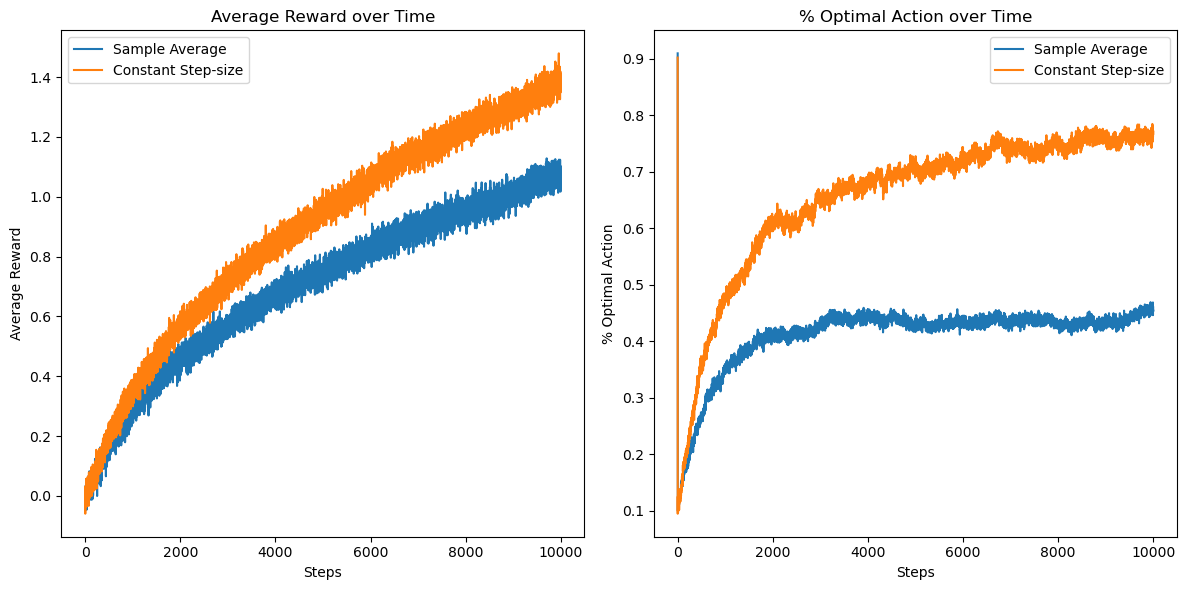

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 매개변수 설정
n_arms = 10
n_steps = 10_000
n_runs = 2_000
epsilon = 0.1
alpha = 0.1
random_walk_std = 0.01

def run_experiment(sample_average: bool = False) -> tuple[np.ndarray, np.ndarray]:
    rewards = np.zeros(n_steps)
    optimal_action_counts = np.zeros(n_steps)

    for _ in range(n_runs):
        q_true = np.zeros(n_arms)        # 행동의 참 가치
        q_estimates = np.zeros(n_arms)   # 행동 가치 추정값
        action_counts = np.zeros(n_arms) # 행동별 선택 횟수

        for step in range(n_steps):
            if np.random.rand() < epsilon:
                action = np.random.choice(n_arms)  # 탐험
            else:
                action = np.argmax(q_estimates)    # 활용

            reward = np.random.normal(q_true[action], 1)  # 정규분포에서 보상 샘플링
            action_counts[action] += 1

            if sample_average:
                q_estimates[action] += (reward - q_estimates[action]) / action_counts[action]
            else:
                q_estimates[action] += alpha * (reward - q_estimates[action])

            rewards[step] += reward
            optimal_action_counts[step] += (action == np.argmax(q_true))

            # 참 가치에 대한 무작위 보행
            q_true += np.random.normal(0, random_walk_std, n_arms)

    rewards /= n_runs
    optimal_action_counts /= n_runs

    return rewards, optimal_action_counts

# 두 방법으로 실험 수행
rewards_sample_average, optimal_action_counts_sample_average = run_experiment(sample_average=True)
rewards_constant_step, optimal_action_counts_constant_step = run_experiment(sample_average=False)

# 결과 시각화
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(rewards_sample_average, label='Sample Average')
plt.plot(rewards_constant_step, label='Constant Step-size')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend()
plt.title('Average Reward over Time')

plt.subplot(1, 2, 2)
plt.plot(optimal_action_counts_sample_average, label='Sample Average')
plt.plot(optimal_action_counts_constant_step, label='Constant Step-size')
plt.xlabel('Steps')
plt.ylabel('% Optimal Action')
plt.legend()
plt.title('% Optimal Action over Time')

plt.tight_layout()
plt.show()


### 설명

1. **초기화:** 팔의 수(`n_arms`), 단계 수(`n_steps`), 실행 횟수(`n_runs`)를 설정하고, `epsilon`과 `alpha`를 정의한다.

2. **`run_experiment` 함수:**
   - 각 단계에 대한 보상과 최적 행동 선택 횟수를 0으로 초기화한다.
   - 결과의 분산을 줄이기 위해 여러 번의 실행을 수행하고 평균을 낸다.
   - 매 단계마다 $\epsilon$-greedy 정책으로 행동을 선택한다.
   - 표본 평균이나 일정 단계 크기 방식 중 하나로 행동 가치 추정값을 갱신한다.
   - 매 단계마다 참 행동 가치에 무작위 보행을 적용한다.

3. **결과 시각화:**
   - 시간에 따른 평균 보상을 그린다.
   - 시간에 따른 최적 행동 선택 비율을 그린다.

### 결과 해석

- **평균 보상 그래프:** 일정 단계 크기 방법이 비정상 환경에 더 빠르게 적응하여, 장기적으로 더 높은 보상을 유지한다.
- **최적 행동 비율 그래프:** 일정 단계 크기 방법이 더 자주 최적 행동을 선택한다. 표본 평균 방법은 모든 과거 보상에 동일한 가중치를 부여하므로, 무작위 보행으로 변하는 최적 행동을 따라잡지 못한다.

이 실험은 비정상 환경에서 표본 평균 방법이 갖는 한계를 분명히 드러내며, 일정 단계 크기 매개변수가 환경 변화에 더 잘 적응한다는 점을 잘 보여 준다.

## Exercise 2.6: 알 수 없는 스파이크

### 설명

낙관적 초기값(optimistic initial values) 방법의 학습 곡선 초반에 나타나는 진동과 스파이크는 다음과 같은 요인들로 설명할 수 있다.

1. **낙관적 초기값:** 이 방법에서는 행동 가치 추정값 $Q(a)$를 참 가치보다 크게 설정한다. 그 결과 에이전트는 초기에 모든 행동이 매우 좋다고 믿게 되어, 다양한 행동을 적극적으로 시도하면서 탐험을 유도한다.

2. **초기의 강한 탐험:** 추정값이 매우 높게 시작하므로, 에이전트는 곧 실제 보상이 추정값보다 낮다는 사실을 알게 된다. 그 결과 추정값을 빠르게 아래쪽으로 조정하는 일련의 갱신이 일어난다.

3. **초기의 급격한 조정:** 초기 단계에서 낙관적 추정값을 보정해 가는 동안 $Q$ 값은 큰 폭으로 흔들린다. 이러한 큰 변동이 평균 보상이나 최적 행동 비율 같은 성능 지표의 진동으로 그대로 드러난다.

4. **최적 행동의 빠른 발견:** 낙관적 초기값은 에이전트가 모든 행동을 비교적 이른 시점에 시도하게 만들어, 최적 행동을 더 빨리 식별하는 효과를 가진다. 그러나 보상의 무작위성과 비정상 동역학 때문에, 이 식별 과정은 결정론적이지 않고 들쭉날쭉하다. 그 결과 최적 행동을 일찍 발견해 활용하는 순간 성능 곡선에서 스파이크가 발생할 수 있다.

5. **무작위 보행의 영향:** 비정상 문제에서는 참 가치가 시간에 따라 변한다. 학습 초반에는 무작위 변동에 의해 일시적으로 가장 좋아 보이는 행동을 에이전트가 우연히 활용할 수 있고, 이때 성능 지표에 일시적인 스파이크가 나타날 수 있다.

6. **높은 분산:** 낙관적 초기값 방법은 본질적으로 강한 탐험을 유도하므로, 학습 초반에 자연스럽게 분산이 커진다. 이러한 큰 분산이 진동과 스파이크 형태로 가시화된다.

### 요약

낙관적 초기값 방법의 곡선 앞부분에서 관찰되는 진동과 스파이크는 다음 세 가지 요인이 결합한 결과이다.

- 과대평가된 추정값을 빠르게 보정하는 과정에서 일어나는 큰 폭의 갱신.
- 초반의 강한 탐험으로 인한 성능의 급격한 흔들림.
- 비정상 환경에서 참 가치가 변함에 따라 일시적으로 우월해 보이는 행동을 활용하면서 발생하는 스파이크.

추정값이 안정화되어 가면서 이러한 초기 불안정성은 점차 사라지고, 장기적으로는 보다 안정적인 성능을 보이게 된다.

## Exercise 2.7: 편향 없는 일정 단계 크기 트릭

$Q_n$이 초기값 편향 없이 지수적으로 최근 보상에 더 큰 가중치를 두는 평균(exponential recency-weighted average)임을 보이고자 한다.

### 분석

1. **$\bar{o}_n$의 재귀적 정의:**

   주어진 재귀식
   $$\bar{o}_n = \bar{o}_{n-1} + \alpha (1 - \bar{o}_{n-1})$$
   은 다음과 같이 다시 쓸 수 있다.
   $$\bar{o}_n = (1 - \alpha) \bar{o}_{n-1} + \alpha$$

2. **초기값:**
   $$\bar{o}_0 = 0$$

3. **재귀식의 해:**

   $\bar{o}_n$의 닫힌 형태 해를 구하기 위해 식을 반복 전개하면 다음과 같다.
   $$\begin{aligned}
   \bar{o}_1 &= \alpha, \\
   \bar{o}_2 &= (1 - \alpha) \alpha + \alpha = \alpha (1 + (1 - \alpha)), \\
   \bar{o}_3 &= (1 - \alpha) \alpha (1 + (1 - \alpha)) + \alpha = \alpha (1 + (1 - \alpha) + (1 - \alpha)^2), \\
   &\vdots \\
   \bar{o}_n &= \alpha \sum_{i=0}^{n-1} (1 - \alpha)^i.
   \end{aligned}$$

   등비급수의 합 공식을 사용하면
   $$\sum_{i=0}^{n-1} (1 - \alpha)^i = \frac{1 - (1 - \alpha)^n}{\alpha}$$
   이므로
   $$\bar{o}_n = \alpha \cdot \frac{1 - (1 - \alpha)^n}{\alpha} = 1 - (1 - \alpha)^n.$$

4. **$\beta_n$을 사용한 행동 가치 갱신:**

   단계 크기 $\beta_n$을 사용하는 행동 가치 갱신식은
   $$Q_{n+1} = Q_n + \beta_n (R_n - Q_n)$$
   이며, $\beta_n = \alpha / \bar{o}_n$을 대입하면
   $$Q_{n+1} = Q_n + \frac{\alpha}{\bar{o}_n} (R_n - Q_n)$$
   가 된다.

5. **최근 가중 평균(recency-weighted average):**

   $\bar{o}_n = 1 - (1 - \alpha)^n$이므로
   $$\beta_n = \frac{\alpha}{1 - (1 - \alpha)^n}$$
   이 된다. $n$이 충분히 커지면 $\bar{o}_n$이 1에 가까워지고, 따라서 $\beta_n$은 일정한 $\alpha$로 수렴한다. 즉 단계 크기 $\beta_n$은 학습 초기에는 큰 값을 가져 초기 추정값의 편향을 제거하고, 시간이 지나면서 자연스럽게 일정 단계 크기 방식으로 수렴한다.

   갱신식을 정리하면
   $$\begin{aligned}
   Q_{n+1} =& Q_n + \beta_n (R_n - Q_n) \\
           =& (1 - \beta_n) Q_n + \beta_n R_n
   \end{aligned}$$
   가 되며, 이는 $Q_{n+1}$이 최근 보상에 더 큰 가중치를 부여하고 과거 보상의 영향력이 지수적으로 감소하는 형태임을 보여 준다. 그리고 $\beta_n$의 정의 덕분에 초기값 편향이 발생하지 않는다.

### 결론

단계 크기 트릭
$$\beta_n \doteq \frac{\alpha}{1 - (1 - \alpha)^n}$$
을 사용하면, $Q_n$은 초기값 편향이 없는 지수적 최근 가중 평균이 된다. 이는 비정상 환경에서 일정 단계 크기가 갖는 적응성을 그대로 유지하면서도, 초기 추정에서 발생하는 편향을 제거하는 효과를 가진다.

## Exercise 2.8: UCB 스파이크

### 11번째 단계의 스파이크에 대한 분석

#### 1. 초기 탐험 단계

처음 10단계 동안 UCB 알고리즘은 $\sqrt{\ln t / N_t(a)}$ 항 덕분에 모든 행동이 적어도 한 번씩은 선택되도록 보장한다. 아직 선택되지 않은 행동에 대해서는 이 항이 무한대 또는 매우 큰 값을 가지므로, 알고리즘은 우선적으로 그러한 행동을 시도하게 된다. 이 단계에서 각 행동에 대한 초기 보상 추정값이 수집된다.

#### 2. 11번째 단계

11번째 단계에 이르면 10개의 행동이 정확히 한 번씩 선택된 상태가 된다. 이때 모든 행동에 대해 $N_t(a) = 1$이고 $t = 11$이므로, $\sqrt{\ln t / N_t(a)}$ 항이 모든 행동에 대해 동일해진다. 결과적으로 알고리즘은 추정 가치 $Q_t(a)$ 가 가장 큰 행동을 선택하게 된다. 초기 탐험에서 평균보다 눈에 띄게 높은 보상을 보였던 행동이 있다면, 11번째 단계에서 그 행동이 다시 선택될 가능성이 매우 높다. 이로 인해 평균 보상에 뚜렷한 스파이크가 나타난다.

#### 3. 이후 단계

11번째 단계 이후에는 UCB 알고리즘이 다시 탐험과 활용 사이의 균형을 잡아 간다. $Q_t(a)$가 큰 행동이 더 자주 선택되지만, $\sqrt{\ln t / N_t(a)}$ 항 덕분에 덜 선택된 행동도 꾸준히 시도된다. 이러한 균형 조정 과정에서 평균 보상은 일시적으로 감소할 수 있다. 11번째 단계에서 우연히 좋게 보였던 행동이 추가 표본을 통해 사실은 차선임이 드러나는 경우가 그 대표적인 예이다.

### $c = 1$일 때 스파이크가 덜 두드러지는 이유

탐험 정도를 조절하는 매개변수 $c$가 작을수록, 알고리즘은 추정 가치 $Q_t(a)$에 더 크게 의존한다. $c = 1$일 때 탐험 항 $c\sqrt{\ln t / N_t(a)}$는 더 작아지므로, 탐험과 활용 사이의 전환이 한층 부드러워진다. 그 결과 11번째 단계 부근의 스파이크 또한 덜 두드러지게 나타난다.

### 결론

UCB 알고리즘 곡선에서 11번째 단계에 스파이크가 나타나는 이유는 다음과 같이 정리할 수 있다.

- 처음 10단계 동안 알고리즘이 모든 행동을 정확히 한 번씩 선택하도록 보장한다.
- 11번째 단계에서는 탐험 항이 모든 행동에 대해 동일해지면서, 초기 탐험으로 가장 높은 추정값을 얻은 행동이 자연스럽게 선택된다.
- 이후에는 추가 탐험과 추정값 정교화가 이어지면서, 일시적으로 평균 보상이 감소한다.

탐험 매개변수 $c$를 작게 잡으면 탐험의 강도가 줄어 곡선이 부드러워지고, 그 결과 11번째 단계의 스파이크 역시 덜 두드러지게 나타난다.

## Exercise 2.9

두 개의 행동 $a_1$, $a_2$와 그 행동 가치 $q_1$, $q_2$에 대해 소프트맥스(softmax) 함수를 다음과 같이 정의한다.

$$P(a_1) = \frac{e^{q_1}}{e^{q_1} + e^{q_2}}, \qquad P(a_2) = \frac{e^{q_2}}{e^{q_1} + e^{q_2}}$$

$P(a_1)$의 분모에서 $e^{q_1}$을 뽑아내어 정리하면

$$P(a_1) = \frac{e^{q_1}}{e^{q_1}(1 + e^{q_2 - q_1})} = \frac{1}{1 + e^{q_2 - q_1}}$$

가 된다. 한편 로지스틱(시그모이드) 함수는

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

로 정의되므로, $x = q_1 - q_2$로 두면

$$\sigma(q_1 - q_2) = \frac{1}{1 + e^{-(q_1 - q_2)}} = \frac{1}{1 + e^{q_2 - q_1}}$$

가 된다. 따라서

$$P(a_1) = \sigma(q_1 - q_2)$$

임을 알 수 있다. 같은 방식으로 $P(a_2)$를 정리하면

$$P(a_2) = \frac{e^{q_2}}{e^{q_2}(1 + e^{q_1 - q_2})} = \frac{1}{1 + e^{q_1 - q_2}} = \sigma(q_2 - q_1)$$

가 된다. 시그모이드 함수는 $\sigma(x) + \sigma(-x) = 1$을 만족하므로

$$\sigma(q_1 - q_2) + \sigma(q_2 - q_1) = 1$$

이 자연스럽게 성립한다. 결과적으로 행동이 두 개일 때 소프트맥스 분포는 통계학과 인공신경망에서 널리 쓰이는 로지스틱(시그모이드) 함수와 정확히 같은 형태로 환원할 수 있다.

## Exercise 2.10

### 문제 정리

두 개의 팔을 가진 밴딧 과제이며, 참 행동 가치는 다음 두 경우 중 하나에 해당한다.

- **경우 A:** 행동 1의 가치는 10, 행동 2의 가치는 20이다.
- **경우 B:** 행동 1의 가치는 90, 행동 2의 가치는 80이다.

각 경우는 확률 0.5로 발생한다. 매 시점 자신이 어느 경우에 놓여 있는지 알 수 없는 상황과, 어느 경우에 놓여 있는지를 알 수 있는 상황을 각각 구분하여 분석한다.

### Part 1. 경우를 알 수 없을 때의 최적 기대 보상

매 시점 자신이 어느 경우에 있는지 알 수 없을 때는, 두 경우에 걸친 평균 보상으로 각 행동을 평가해야 한다.

**행동 1의 기대 보상:**
$$E[R_1] = 0.5 \times 10 + 0.5 \times 90 = 50$$

**행동 2의 기대 보상:**
$$E[R_2] = 0.5 \times 20 + 0.5 \times 80 = 50$$

두 행동의 기대 보상이 모두 50으로 같으므로, 어느 행동을 선택하더라도 기대 보상은 50이 된다.

### Part 2. 경우를 알 수 있을 때의 최적 기대 보상

이번에는 자신이 경우 A인지 경우 B인지를 알 수 있다고 하자. 이는 일종의 연관 탐색(associative search) 과제가 된다.

**전략:**
- **경우 A:** 행동 2를 선택한다(20 > 10).
- **경우 B:** 행동 1을 선택한다(90 > 80).

**기대 보상 계산:**

- 경우 A에서 행동 2를 선택하면 보상은 20이다.
- 경우 B에서 행동 1을 선택하면 보상은 90이다.

각 경우가 확률 0.5로 발생하므로 기대 보상은 다음과 같다.
$$E[R] = 0.5 \times 20 + 0.5 \times 90 = 55$$

### 요약

- 자신이 어느 경우에 있는지 알 수 없을 때는 어떤 행동을 선택해도 기대 보상이 50으로 같다.
- 자신이 어느 경우에 있는지 알 수 있을 때는 각 경우마다 더 큰 가치를 가진 행동을 선택함으로써 기대 보상 55를 달성할 수 있다.

따라서 이 과제에서 얻을 수 있는 최대 기대 보상은 **55** 이며, 이는 각 경우에 맞춰 최적 행동을 선택할 때 달성된다.

## Exercise 2.11

아래 코드는 비정상(nonstationary) 10팔 밴딧 문제에서 일정 단계 크기 $\alpha = 0.1$을 사용하는 $\epsilon$-greedy 알고리즘의 장기 성능을 측정한다. 보상의 참값이 무작위 보행을 통해 천천히 변하는 환경에서, 마지막 100,000 단계의 평균 보상을 출력하고, 이동 평균 형태로 성능 곡선을 그린다.

마지막 100,000 단계의 평균 보상: 5.746607859059822


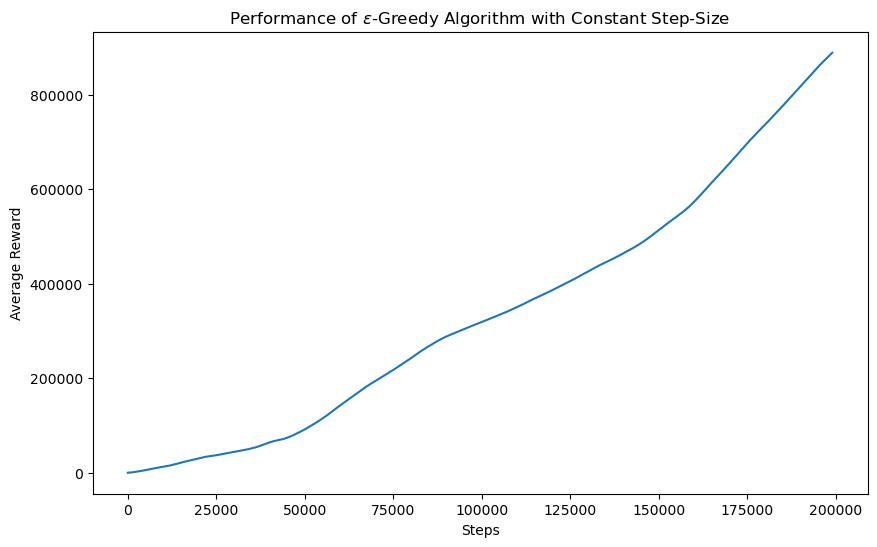

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 매개변수
num_actions = 10
num_steps = 200000
alpha = 0.1
epsilon = 0.1

# 비정상 밴딧 문제 정의
class NonstationaryBandit:
    def __init__(self, num_actions: int) -> None:
        self.num_actions = num_actions
        self.q_true = np.zeros(num_actions)

    def step(self, action: int | np.integer) -> float:
        reward = np.random.randn() + self.q_true[action]
        # 참 가치를 천천히 변화시키는 무작위 보행
        self.q_true += np.random.normal(0, 0.01, self.num_actions)
        return reward

# 일정 단계 크기를 사용하는 엡실론-탐욕적 알고리즘
def epsilon_greedy_bandit(alpha: float, epsilon: float, num_actions: int, num_steps: int) -> np.ndarray:
    bandit = NonstationaryBandit(num_actions)
    q_estimates = np.zeros(num_actions)
    rewards = np.zeros(num_steps)

    for step in range(num_steps):
        if np.random.rand() < epsilon:
            action = np.random.choice(num_actions)
        else:
            action = np.argmax(q_estimates)

        reward = bandit.step(action)
        q_estimates[action] += alpha * (reward - q_estimates[action])
        rewards[step] = reward

    return rewards

# 시뮬레이션 실행
rewards = epsilon_greedy_bandit(alpha, epsilon, num_actions, num_steps)

# 마지막 100,000 단계에 대한 평균 보상
average_reward_last_100k = np.mean(rewards[-100000:])

print(f"마지막 100,000 단계의 평균 보상: {average_reward_last_100k}")

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(np.convolve(rewards, np.ones(1000)/1000, mode='valid'))
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title(r'Performance of $\epsilon$-Greedy Algorithm with Constant Step-Size')
plt.show()